In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')


In [2]:
df= pd.read_csv('better data.csv')
print(df)


             ID                                     Name           Area  \
0        ADHI_1         VINA NORD (BINI) a PONT DE BEREM    1566.639483   
1       ADHI_10         SANAGA a SAKBAYEME (SONGMBENGUE)  127871.199700   
2      ADHI_100                      KOUILOU a KAKAMOEKA   64602.869040   
3     ADHI_1000                           DARGOL at TERA    2612.515260   
4     ADHI_1001                    SIRBA at GARBE-KOUROU   40287.678410   
...         ...                                      ...            ...   
1461   ADHI_995              MAPUTO at WESTOE (27632207)     507.011330   
1462   ADHI_996    BONNIE BROOK at BROADHOLMS (27632208)     103.324895   
1463   ADHI_997  NGWEMPISI at BUSHMANS SPRUIT (27632204)     451.578496   
1464   ADHI_998      SWARTWATER at ZWARTWATER (27632206)     166.725785   
1465   ADHI_999                        GOROUOL at DOLBEL    7837.465873   

      Mean_altitude  Maximum_altitude  Minimum_altitude  \
0            1111.0              1241   

In [3]:
df_clean = df.dropna(subset=df.columns[3:26])  # Drop rows where X or y has NaN
X = df_clean.iloc[:, 2:24].values
y = df_clean.iloc[:, 25].values

In [4]:
print(X.shape)  # Prints (rows, columns)


(1463, 22)


In [5]:
y

array([  98.45, 6590.  , 2660.5 , ...,   14.55,    8.32,  132.  ])

In [136]:
X

array([[1.56663948e+03, 1.11100000e+03, 1.24100000e+03, ...,
        7.61451324e-01, 2.45101331e+02, 1.73388052e+00],
       [1.27871200e+05, 8.50000000e+02, 2.19300000e+03, ...,
        6.57690299e-01, 3.12068774e+03, 2.44355420e+00],
       [6.46028690e+04, 4.14000000e+02, 8.51000000e+02, ...,
        6.46288853e-01, 2.22364181e+03, 2.44961007e+00],
       ...,
       [4.51578496e+02, 1.49600000e+03, 1.61000000e+03, ...,
        8.62185942e-01, 1.48294079e+02, 1.95395796e+00],
       [1.66725785e+02, 1.33700000e+03, 1.40900000e+03, ...,
        1.05135831e+00, 8.93473240e+01, 1.93748431e+00],
       [7.83746587e+03, 2.88100000e+02, 3.48000000e+02, ...,
        1.36310508e-01, 5.72464999e+02, 1.81058592e+00]])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [138]:
from sklearn.ensemble import RandomForestRegressor
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Define the parameter space for hyperparameter tuning
param_space = {
    'n_estimators': Integer(10, 1000),  # More flexible range
    'max_depth': Integer(1, 100),
    'max_features': Real(0.1, 1.0, prior='uniform'),
    'min_samples_leaf': Integer(1, 20),
    'min_samples_split': Integer(2, 20)
}

# Define the Random Forest Regressor
reg = RandomForestRegressor(random_state=42)

# Define the scoring function (negative MSE since BayesSearchCV maximizes the score)
scoring = make_scorer(mean_squared_error, greater_is_better=False)

# Create a BayesSearchCV object for hyperparameter tuning
opt = BayesSearchCV(
    reg,
    param_space,
    scoring=scoring,  # Use negative MSE as the metric
    cv=10,
    n_iter=100,  # Number of iterations for Bayesian Optimization
    n_jobs=-1,
    random_state=42
)

# Fit the model to training data
opt.fit(X_train, y_train)

# Print the best hyperparameters
print("Best hyperparameters:", opt.best_params_)

# Access the best model
best_rf = opt.best_estimator_

# Evaluate the best model on the test set using RMSE
y_pred = best_rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)


Best hyperparameters: OrderedDict([('max_depth', 100), ('max_features', 0.1), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 10)])
Test RMSE: 1071.1565126009232


In [139]:
from joblib import dump

# Save the trained model to a file

# Later, load it back with:
# from joblib import load
# loaded_model = load('random_forest_model.joblib')# Save the model
dump(best_rf, 'RF.joblib')

from joblib import load
import numpy as np

model = load('RF.joblib')



In [140]:
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Define the parameter space for XGBoost hyperparameter tuning
param_space = {
    'n_estimators': Integer(10, 1000),
    'max_depth': Integer(1, 20),  # XGBoost typically uses shallower trees
    'learning_rate': Real(0.001, 0.3, prior='log-uniform'),  # Also called eta
    'subsample': Real(0.5, 1.0, prior='uniform'),
    'colsample_bytree': Real(0.5, 1.0, prior='uniform'),
    'gamma': Real(0, 5, prior='uniform'),  # Minimum loss reduction to make a split
    'reg_alpha': Real(0, 10, prior='uniform'),  # L1 regularization
    'reg_lambda': Real(0, 10, prior='uniform')  # L2 regularization
}

# Define the XGBoost Regressor
reg = XGBRegressor(random_state=42, n_jobs=-1)

# Define the scoring function (negative MSE since BayesSearchCV maximizes the score)
scoring = make_scorer(mean_squared_error, greater_is_better=False)

# Create a BayesSearchCV object for hyperparameter tuning
opt = BayesSearchCV(
    reg,
    param_space,
    scoring=scoring,
    cv=10,
    n_iter=100,  # Number of iterations for Bayesian Optimization
    n_jobs=-1,   # Note: XGBoost already uses n_jobs in the estimator
    random_state=42
)

# Fit the model to training data
opt.fit(X_train, y_train)

# Print the best hyperparameters
print("Best hyperparameters:", opt.best_params_)

# Access the best model
best_xgb = opt.best_estimator_

# Evaluate the best model on the test set using RMSE
y_pred = best_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)

Best hyperparameters: OrderedDict([('colsample_bytree', 1.0), ('gamma', 4.482380294869095), ('learning_rate', 0.04494259269103703), ('max_depth', 1), ('n_estimators', 846), ('reg_alpha', 10.0), ('reg_lambda', 0.0), ('subsample', 0.5)])
Test RMSE: 996.1533893178915


In [141]:
from joblib import dump

# Save the best XGBoost model
dump(best_xgb, 'XGB.joblib')

# dump(best_xgb, 'optimized_xgboost.joblib')

['XGB.joblib']

In [7]:
from sklearn.svm import SVR
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from joblib import dump

# Define SVM parameter space
from skopt.space import Real, Categorical



param_space = {
    'C': Real(1e-3, 500, prior='log-uniform'),              # Broader range for regularization
    'gamma': Real(1e-6, 10, prior='log-uniform'),           # More flexibility on the kernel coefficient
    'epsilon': Real(1e-4, 1.0, prior='log-uniform'),        # SVR epsilon-insensitive zone
    'kernel': Categorical(['rbf']),      # Trying additional kernels
    'degree': Integer(2, 5),                                # For polynomial kernel (if used)
    'shrinking': Categorical([True, False])                 # Optional: use shrinking heuristic or not
}


# Initialize SVM
svm = SVR()

# Bayesian optimization
opt = BayesSearchCV(
    svm,
    param_space,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

opt.fit(X_train, y_train)

# Best model
best_svm = opt.best_estimator_
print("Best SVM params:", opt.best_params_)

# Save model
dump(best_svm, 'SVM.joblib')

Best SVM params: OrderedDict([('C', 499.99999999999994), ('degree', 2), ('epsilon', 1.0), ('gamma', 1e-06), ('kernel', 'rbf'), ('shrinking', False)])


['SVM.joblib']

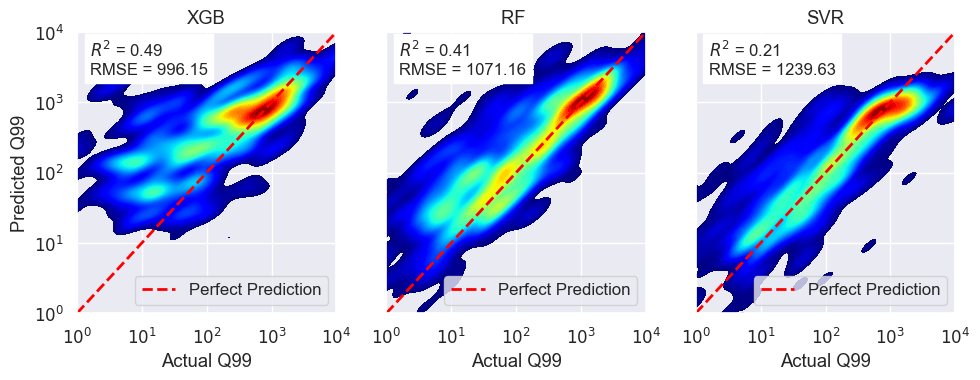

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.cm as cm
import joblib

sns.set_theme(style="darkgrid", font_scale=1.1)

models = [
    ("XGB", "XGB.joblib"),
    ("RF ", "RF.joblib"),
    ("SVR", "SVM.joblib")
]

x_min, x_max = 1e0, 1e4
y_min, y_max = x_min, x_max

def clean_data(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if isinstance(y_true, np.ma.MaskedArray):
        y_true = y_true.filled(np.nan)
    if isinstance(y_pred, np.ma.MaskedArray):
        y_pred = y_pred.filled(np.nan)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return y_true[mask], y_pred[mask]

fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)

for ax, (title, model_path) in zip(axes, models):
    model = joblib.load(model_path)
    
    y_pred = model.predict(X_test)
    y_test_clean, y_pred_clean = clean_data(y_test, y_pred)
    
    r2 = r2_score(y_test_clean, y_pred_clean)
    rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
    
    log_y_true = np.log10(y_test_clean)
    log_y_pred = np.log10(y_pred_clean)
    
    sns.kdeplot(
        x=log_y_true,
        y=log_y_pred,
        fill=True,
        cmap=cm.get_cmap('jet'),
        bw_adjust=0.5,
        thresh=0.05,
        levels=100,
        ax=ax
    )
    
    log_bins = np.linspace(np.log10(x_min), np.log10(x_max), 100)
    ax.plot(log_bins, log_bins, '--', color='red', linewidth=2, label='Perfect Prediction')
    
    ax.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_xticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    ax.set_yticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_yticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    
    ax.set_xlim(np.log10(x_min), np.log10(x_max))
    ax.set_ylim(np.log10(y_min), np.log10(y_max))
    
    ax.set_xlabel('Actual Q99')
    ax.set_ylabel('Predicted Q99')
    ax.set_title(title)
    
    ax.text(0.05, 0.85,
            f'$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f}',
            transform=ax.transAxes,
            fontsize=12,
            bbox=dict(facecolor='white', alpha=1))
    
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('comparison.tif', dpi=300, bbox_inches='tight')
plt.show()


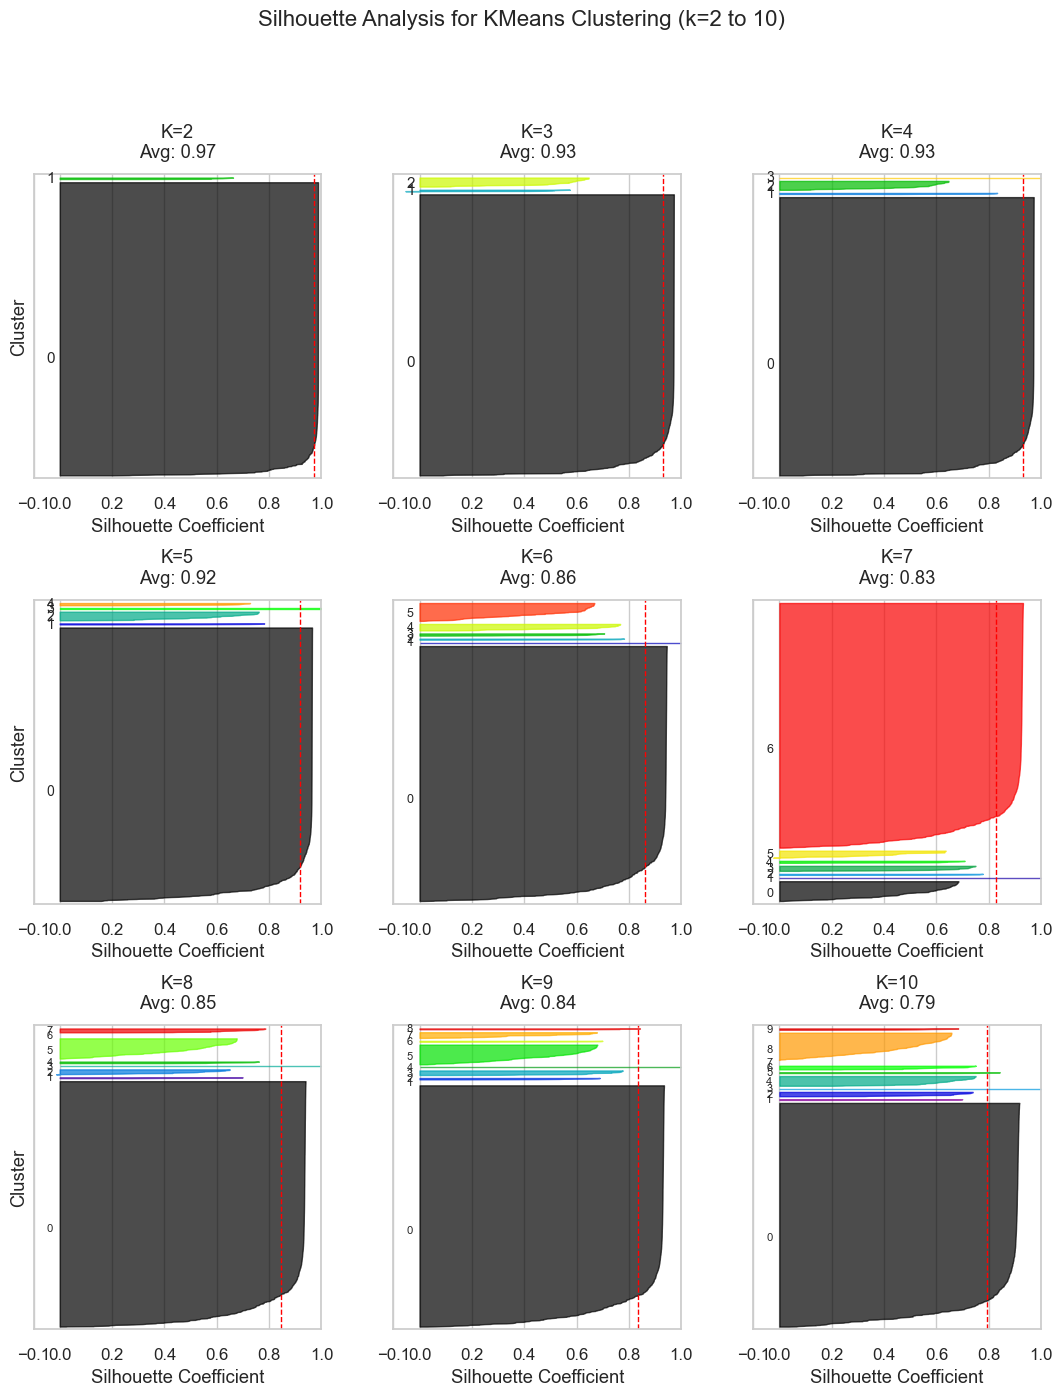

In [218]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

sns.set_theme(style="whitegrid", font_scale=1.1)

range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]

fig, axs = plt.subplots(3, 3, figsize=(13, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.25)
axs = axs.ravel()

for idx, n_clusters in enumerate(range_n_clusters):
    ax = axs[idx]
    
    # Dynamic sizing parameters
    base_gap = 15  # Increased from 10 to 15
    font_size = max(8, 12 - n_clusters//2)  # Scale font size with clusters
    
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X) + (n_clusters + 1) * base_gap])
    
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)

    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    
    y_lower = base_gap  # Start with base gap
    for i in range(n_clusters):
        ith_cluster_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_values.sort()
        
        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        
        # Place cluster number with dynamic positioning
        label_y = y_lower + 0.4 * size_cluster_i  # Slightly lower position
        ax.text(-0.05, label_y, str(i), 
                fontsize=font_size, 
                va='center')
        
        y_lower = y_upper + base_gap  # Use consistent gap
    
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=1)
    ax.set_title(f'K={n_clusters}\nAvg: {silhouette_avg:.2f}', pad=12)
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster" if idx in [0, 3, 6] else "")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.suptitle("Silhouette Analysis for KMeans Clustering (k=2 to 10)", 
             fontsize=16, y=0.99)
plt.show()

In [219]:
X.shape

(1463, 22)

# k means clustering k=2

In [278]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

param_space = {
    'n_estimators': Integer(50, 1000),
    'max_depth': Integer(3, 12),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'gamma': Real(0, 5),
    'reg_alpha': Real(0, 10),
    'reg_lambda': Real(0, 10)
}

cluster_models = {}
results = {}

for cluster in range(K):
    print(f"\nTraining XGBoost model for Cluster {cluster+1}/{K}")
    
    train_mask = (train_clusters == cluster)
    test_mask = (test_clusters == cluster)
    
    X_train_cl = X_train[train_mask]
    y_train_cl = y_train[train_mask]
    X_test_cl = X_test[test_mask]
    y_test_cl = y_test[test_mask]
    
    if len(X_train_cl) == 0:
        print(f"Skipping cluster {cluster} - no training samples")
        continue
    
    xgb = XGBRegressor(random_state=42, n_jobs=-1)
    scoring = make_scorer(mean_squared_error, greater_is_better=False)
    
    opt = BayesSearchCV(
        xgb,
        param_space,
        n_iter=50,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )
    
    opt.fit(X_train_cl, y_train_cl)
    
    cluster_models[cluster] = opt.best_estimator_
    
    if len(X_test_cl) > 0:
        y_pred = opt.best_estimator_.predict(X_test_cl)
        rmse = np.sqrt(mean_squared_error(y_test_cl, y_pred))
        results[cluster] = {
            'train_samples': len(X_train_cl),
            'test_samples': len(X_test_cl),
            'rmse': rmse,
            'best_params': opt.best_params_,
            'model': opt.best_estimator_
        }
        print(f"Cluster {cluster} RMSE: {rmse:.4f}")
    else:
        print(f"Cluster {cluster} has no test samples")

print("\nCluster Performance Summary:")
for cluster, res in results.items():
    print(f"Cluster {cluster}:")
    print(f"- Train samples: {res['train_samples']}")
    print(f"- Test samples: {res['test_samples']}")
    print(f"- Test RMSE: {res['rmse']:.4f}")
    print(f"- Best params: {res['best_params']}\n")


Training XGBoost model for Cluster 1/2
Cluster 0 RMSE: 238.4628

Training XGBoost model for Cluster 2/2
Cluster 1 RMSE: 986.1346

Cluster Performance Summary:
Cluster 0:
- Train samples: 496
- Test samples: 223
- Test RMSE: 238.4628
- Best params: OrderedDict([('colsample_bytree', 0.6065687826719878), ('gamma', 1.7685699160505197), ('learning_rate', 0.02221876239806809), ('max_depth', 3), ('n_estimators', 1000), ('reg_alpha', 5.875338832309436), ('reg_lambda', 10.0), ('subsample', 0.9798260418706827)])

Cluster 1:
- Train samples: 528
- Test samples: 216
- Test RMSE: 986.1346
- Best params: OrderedDict([('colsample_bytree', 0.8159294873624924), ('gamma', 0.8915916689222096), ('learning_rate', 0.01822326912033851), ('max_depth', 3), ('n_estimators', 202), ('reg_alpha', 8.739408179676095), ('reg_lambda', 1.2629683246652665), ('subsample', 0.8826787954367874)])



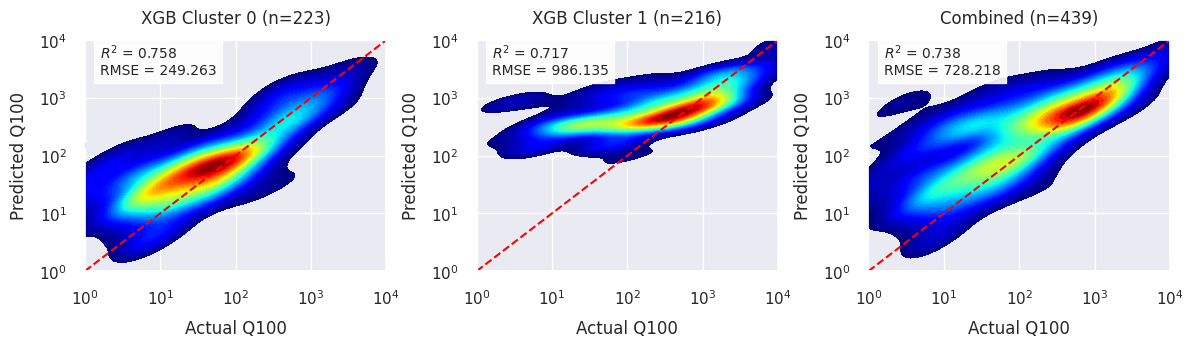

In [279]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.cm as cm

sns.set_theme(style="darkgrid", font_scale=1)
plt.rcParams['font.family'] = 'DejaVu Sans'  # Match font style

def create_cluster_plot(y_true, y_pred, title, ax, x_min=1e0, x_max=1e4):
    """Create density plot for a single cluster"""
    y_true, y_pred = clean_data(y_true, y_pred)
    
    log_y_true = np.log10(y_true)
    log_y_pred = np.log10(y_pred)
    
    sns.kdeplot(
        x=log_y_true,
        y=log_y_pred,
        fill=True,
        cmap=cm.get_cmap('jet'),
        bw_adjust=0.8,
        thresh=0.05,
        levels=50,
        ax=ax
    )
    
    log_bins = np.linspace(np.log10(x_min), np.log10(x_max), 100)
    ax.plot(log_bins, log_bins, '--', color='red', linewidth=1.5, label='1:1 line')
    
    ax.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_xticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    ax.set_yticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_yticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    
    ax.set_xlim(np.log10(x_min), np.log10(x_max))
    ax.set_ylim(np.log10(x_min), np.log10(x_max))
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.text(0.05, 0.85, 
            f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}', 
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.9))
    
    ax.set_title(title, pad=12)
    ax.set_xlabel('Actual Q100', labelpad=8)
    ax.set_ylabel('Predicted Q100', labelpad=8)

fig = plt.figure(figsize=(14, 3))
gs = fig.add_gridspec(1, K+1, wspace=0.3)

all_y_test = []
all_y_pred = []

for cluster in range(K):
    ax = fig.add_subplot(gs[0, cluster])
    if cluster not in results:
        ax.axis('off')
        continue
        
    test_mask = (test_clusters == cluster)
    y_test_cl = y_test[test_mask]
    y_pred_cl = results[cluster]['model'].predict(X_test[test_mask])
    
    all_y_test.append(y_test_cl)
    all_y_pred.append(y_pred_cl)
    
    create_cluster_plot(y_test_cl, y_pred_cl, 
                       f'XGB Cluster {cluster} (n={len(y_test_cl)})', 
                       ax)

ax_combined = fig.add_subplot(gs[0, -1])
y_test_all = np.concatenate(all_y_test)
y_pred_all = np.concatenate(all_y_pred)
create_cluster_plot(y_test_all, y_pred_all, 
                   f'Combined (n={len(y_test_all)})', 
                   ax_combined)

plt.tight_layout()
#plt.savefig('XGB k=2.tif', dpi=300, bbox_inches='tight')

plt.show()

In [280]:
from joblib import dump

dump(scaler, 'cluster_scaler.joblib')       
dump(kmeans, 'cluster_kmeans.joblib')        

for cluster, model in cluster_models.items():
    dump(model, f'xgb_cluster_{cluster}.joblib')

cluster_info = {
    'n_clusters': K,
    'train_distribution': np.bincount(train_clusters),
    'test_distribution': np.bincount(test_clusters)
}
dump(cluster_info, 'cluster_info.joblib')

['cluster_info.joblib']

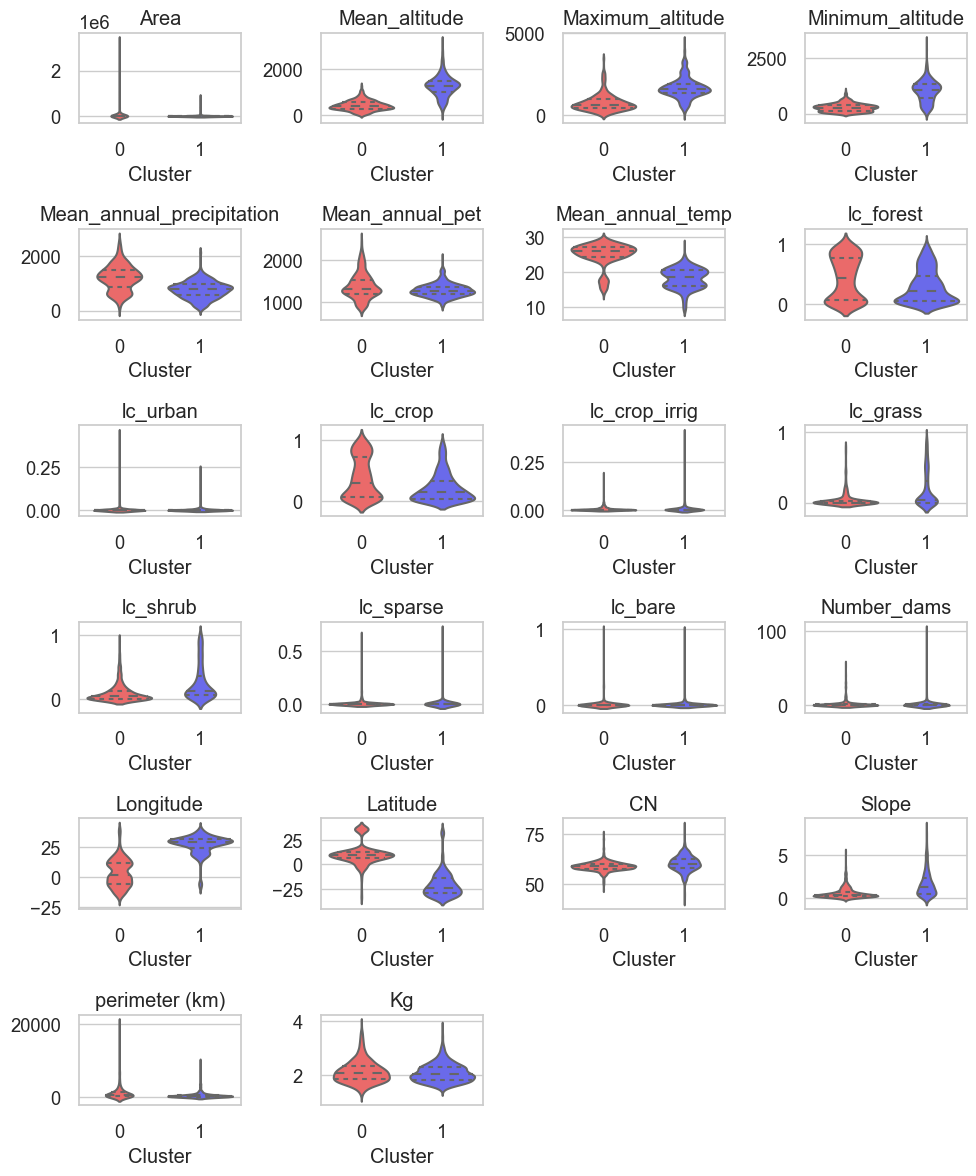

In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
sns.set_theme(style="whitegrid", font_scale=1.2)

df = pd.read_csv("better data.csv")

features = ['Area', 'Mean_altitude', 'Maximum_altitude', 'Minimum_altitude',
    'Mean_annual_precipitation', 'Mean_annual_pet', 'Mean_annual_temp',
    'lc_forest', 'lc_urban', 'lc_crop', 'lc_crop_irrig', 'lc_grass',
    'lc_shrub', 'lc_sparse', 'lc_bare', 'Number_dams', 'Longitude', 'Latitude',
    'CN', 'Slope', 'perimeter (km)', 'Kg'
]

df_clean = df.dropna(subset=features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features])
palette = sns.color_palette("seismic_r", K)  # One color per cluster

K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_clean['Cluster'] = clusters

for i in range(K):
    cluster_df = df_clean[df_clean['Cluster'] == i]
    cluster_df.to_csv(f"cluster_{i}.csv", index=False)

num_features = len(features)
cols = 4  
rows = int(np.ceil(num_features / cols))

plt.figure(figsize=(2.5 * cols, 2 * rows))
for i, feature in enumerate(features):
    plt.subplot(rows, cols, i + 1)
    sns.violinplot(data=df_clean, x='Cluster', y=feature, palette=palette, inner='quartile')
    plt.title(feature)
    plt.xlabel('Cluster')
    plt.ylabel('')

plt.tight_layout()
plt.show()


No model for Cluster 2


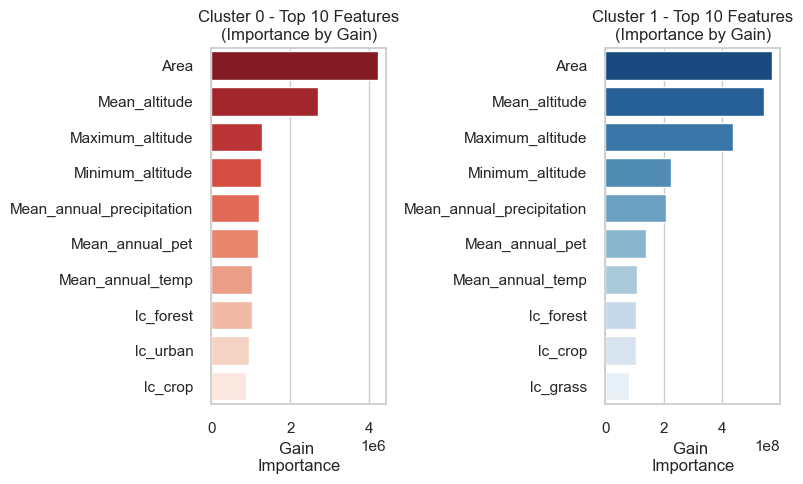

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load
from xgboost import plot_importance
import numpy as np

sns.set_theme(style="whitegrid")

feature_names = ['Area', 'Mean_altitude', 'Maximum_altitude', 'Minimum_altitude',
                 'Mean_annual_precipitation', 'Mean_annual_pet', 'Mean_annual_temp',
                 'lc_forest', 'lc_urban', 'lc_crop', 'lc_crop_irrig', 'lc_grass',
                 'lc_shrub', 'lc_sparse', 'lc_bare', 'Number_dams', 'Longitude', 'Latitude',
                 'CN', 'Slope', 'perimeter (km)', 'Kg']

plt.figure(figsize=(12, 5))
for cluster in range(3):  # Change 3 to your K value
    try:
        model = load(f'xgb_cluster_{cluster}.joblib')
        
        importance = model.get_booster().get_score(importance_type='gain')
        
        sorted_idx = np.argsort(list(importance.values()))[::-1]
        sorted_features = [feature_names[int(k[1:])] for k in importance.keys()]
        sorted_values = [list(importance.values())[i] for i in sorted_idx]

        if cluster == 0:
            palette = 'Reds_r'  # For cluster 0
        elif cluster == 1:
            palette = 'Blues_r'   # For cluster 1
        else:
            palette = 'cividis'  # For cluster 2

        plt.subplot(1, 3, cluster+1)
        sns.barplot(x=sorted_values[:10], y=sorted_features[:10], palette=palette)
        plt.title(f'Cluster {cluster} - Top 10 Features\n(Importance by Gain)')
        plt.xlabel('Gain \nImportance')
        plt.ylabel('')
        
    except FileNotFoundError:
        print(f"No model for Cluster {cluster}")
        continue

plt.tight_layout()
plt.savefig('cluster_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


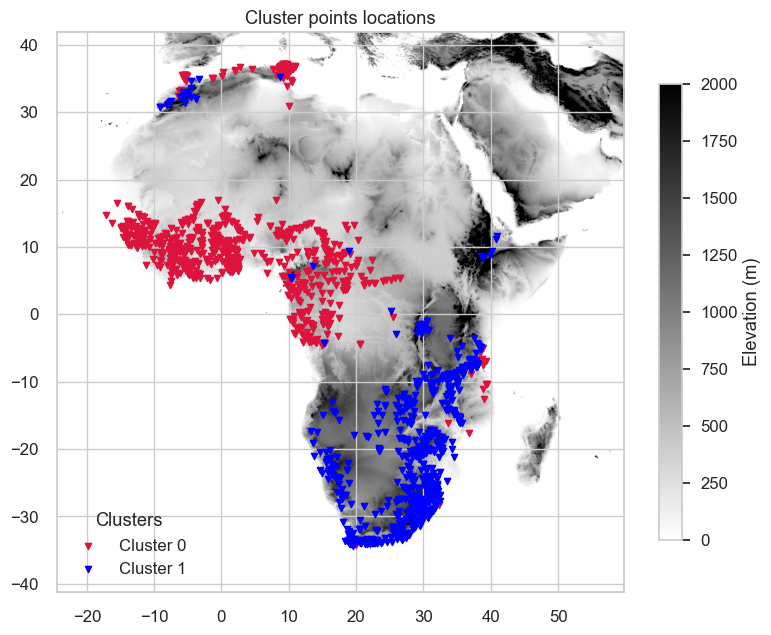

In [185]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", font_scale=1.1)

shapefile_path = 'maghreb.shp'
elevation_tif_path = 'elevation final.tif'
num_clusters = 2  

gdf_outline = gpd.read_file(shapefile_path)

with rasterio.open(elevation_tif_path) as src:
    elevation_bounds = src.bounds
    elevation_crs = src.crs

palette = sns.color_palette("Paired", num_clusters)
palette = ["crimson", "blue", "red"]  # Or pick any 3 hex or named colors

elevation_min = 0     # Set your minimum elevation value
elevation_max = 2000  # Set your maximum elevation value
elevation_cmap = 'binary'  # Colormap: 'terrain', 'viridis', 'gist_earth', etc.

fig, ax = plt.subplots(figsize=(8, 8))

with rasterio.open(elevation_tif_path) as src:
    img = show(
        src, 
        ax=ax, 
        cmap=elevation_cmap,
        vmin=elevation_min,
        vmax=elevation_max,
        alpha=1
    )

cbar = plt.colorbar(ax.get_images()[0], ax=ax, shrink=0.6)
cbar.set_label('Elevation (m)')

gdf_outline.boundary.plot(ax=ax, edgecolor='none', linewidth=0.5)

for cluster_id in range(num_clusters):
    cluster_path = f"cluster_{cluster_id}.csv"
    if os.path.exists(cluster_path):
        df_cluster = pd.read_csv(cluster_path)
        gdf_cluster = gpd.GeoDataFrame(
            df_cluster,
            geometry=gpd.points_from_xy(df_cluster['Longitude'], df_cluster['Latitude']),
            crs="EPSG:4326"
        )
        gdf_cluster = gdf_cluster.to_crs(elevation_crs)

        gdf_cluster.plot(
            ax=ax,
            color=palette[cluster_id],
            markersize=20,
            marker='v',
            label=f"Cluster {cluster_id}"
        )
    else:
        print(f"Warning: {cluster_path} not found.")

ax.set_xlim([elevation_bounds.left, elevation_bounds.right])
ax.set_ylim([elevation_bounds.bottom, elevation_bounds.top])

ax.legend(title="Clusters", loc="lower left")
ax.set_title("Cluster points locations")
plt.tight_layout()
plt.savefig('cluster_locations.png', dpi=300, bbox_inches='tight')
plt.show()

# RF

In [245]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor  # Changed import
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical  # Added Categorical
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Data scaling remains the same
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

# Updated parameter space for Random Forest
param_space = {
    'n_estimators': Integer(50, 1000),
    'max_depth': Integer(3, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 20),
    'max_features': Real(0.1, 1.0),
    'max_samples': Real(0.5, 1.0)
}

cluster_models = {}
results = {}

for cluster in range(K):
    print(f"\nTraining Random Forest model for Cluster {cluster+1}/{K}")  # Updated text
    
    train_mask = (train_clusters == cluster)
    test_mask = (test_clusters == cluster)
    
    X_train_cl = X_train[train_mask]
    y_train_cl = y_train[train_mask]
    X_test_cl = X_test[test_mask]
    y_test_cl = y_test[test_mask]
    
    if len(X_train_cl) == 0:
        print(f"Skipping cluster {cluster} - no training samples")
        continue
    
    # Initialize Random Forest instead of XGBoost
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    scoring = make_scorer(mean_squared_error, greater_is_better=False)
    
    opt = BayesSearchCV(
        rf,  # Changed estimator
        param_space,
        n_iter=50,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )
    
    opt.fit(X_train_cl, y_train_cl)
    
    cluster_models[cluster] = opt.best_estimator_
    
    if len(X_test_cl) > 0:
        y_pred = opt.best_estimator_.predict(X_test_cl)
        rmse = np.sqrt(mean_squared_error(y_test_cl, y_pred))
        results[cluster] = {
            'train_samples': len(X_train_cl),
            'test_samples': len(X_test_cl),
            'rmse': rmse,
            'best_params': opt.best_params_,
            'model': opt.best_estimator_
        }
        print(f"Cluster {cluster} RMSE: {rmse:.4f}")
    else:
        print(f"Cluster {cluster} has no test samples")

print("\nCluster Performance Summary:")
for cluster, res in results.items():
    print(f"Cluster {cluster}:")
    print(f"- Train samples: {res['train_samples']}")
    print(f"- Test samples: {res['test_samples']}")
    print(f"- Test RMSE: {res['rmse']:.4f}")
    print(f"- Best params: {res['best_params']}\n")


Training Random Forest model for Cluster 1/2
Cluster 0 RMSE: 247.5173

Training Random Forest model for Cluster 2/2
Cluster 1 RMSE: 1047.7766

Cluster Performance Summary:
Cluster 0:
- Train samples: 496
- Test samples: 223
- Test RMSE: 247.5173
- Best params: OrderedDict([('max_depth', 17), ('max_features', 0.3469982473162821), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 1000)])

Cluster 1:
- Train samples: 528
- Test samples: 216
- Test RMSE: 1047.7766
- Best params: OrderedDict([('max_depth', 18), ('max_features', 1.0), ('max_samples', 0.9829560216588367), ('min_samples_leaf', 3), ('min_samples_split', 2), ('n_estimators', 1000)])



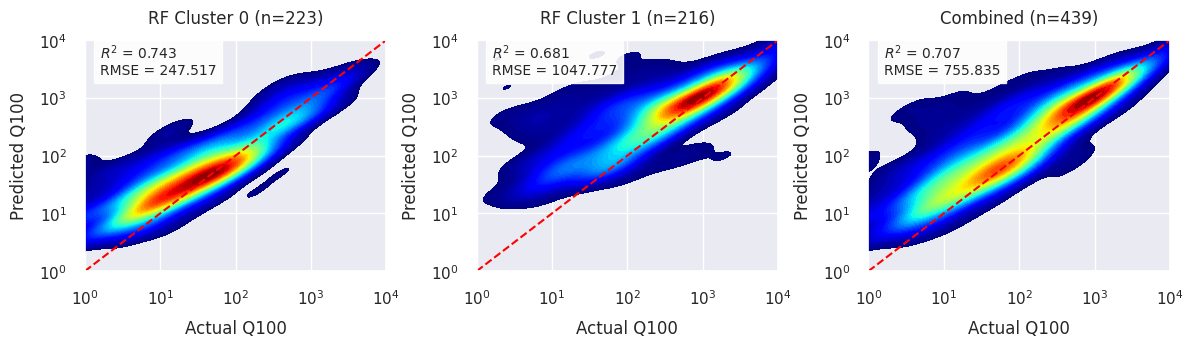

In [246]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.cm as cm

sns.set_theme(style="darkgrid", font_scale=1)
plt.rcParams['font.family'] = 'DejaVu Sans'  # Match font style

def create_cluster_plot(y_true, y_pred, title, ax, x_min=1e0, x_max=1e4):
    """Create density plot for a single cluster"""
    y_true, y_pred = clean_data(y_true, y_pred)
    
    log_y_true = np.log10(y_true)
    log_y_pred = np.log10(y_pred)
    
    sns.kdeplot(
        x=log_y_true,
        y=log_y_pred,
        fill=True,
        cmap=cm.get_cmap('jet'),
        bw_adjust=0.8,
        thresh=0.05,
        levels=50,
        ax=ax
    )
    
    log_bins = np.linspace(np.log10(x_min), np.log10(x_max), 100)
    ax.plot(log_bins, log_bins, '--', color='red', linewidth=1.5, label='1:1 line')
    
    ax.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_xticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    ax.set_yticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_yticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    
    ax.set_xlim(np.log10(x_min), np.log10(x_max))
    ax.set_ylim(np.log10(x_min), np.log10(x_max))
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.text(0.05, 0.85, 
            f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}', 
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.9))
    
    ax.set_title(title, pad=12)
    ax.set_xlabel('Actual Q100', labelpad=8)
    ax.set_ylabel('Predicted Q100', labelpad=8)

fig = plt.figure(figsize=(14, 3))
gs = fig.add_gridspec(1, K+1, wspace=0.3)

all_y_test = []
all_y_pred = []

for cluster in range(K):
    ax = fig.add_subplot(gs[0, cluster])
    if cluster not in results:
        ax.axis('off')
        continue
        
    test_mask = (test_clusters == cluster)
    y_test_cl = y_test[test_mask]
    y_pred_cl = results[cluster]['model'].predict(X_test[test_mask])
    
    all_y_test.append(y_test_cl)
    all_y_pred.append(y_pred_cl)
    
    create_cluster_plot(y_test_cl, y_pred_cl, 
                       f'RF Cluster {cluster} (n={len(y_test_cl)})', 
                       ax)

ax_combined = fig.add_subplot(gs[0, -1])
y_test_all = np.concatenate(all_y_test)
y_pred_all = np.concatenate(all_y_pred)
create_cluster_plot(y_test_all, y_pred_all, 
                   f'Combined (n={len(y_test_all)})', 
                   ax_combined)

plt.tight_layout()
plt.savefig('RF k=2.tif', dpi=300, bbox_inches='tight')

plt.show()

In [247]:
from joblib import dump

dump(scaler, 'cluster_scaler.joblib')       
dump(kmeans, 'cluster_kmeans.joblib')        

for cluster, model in cluster_models.items():
    dump(model, f'rf_cluster_{cluster}.joblib')

cluster_info = {
    'n_clusters': K,
    'train_distribution': np.bincount(train_clusters),
    'test_distribution': np.bincount(test_clusters)
}
dump(cluster_info, 'cluster_info.joblib')

['cluster_info.joblib']

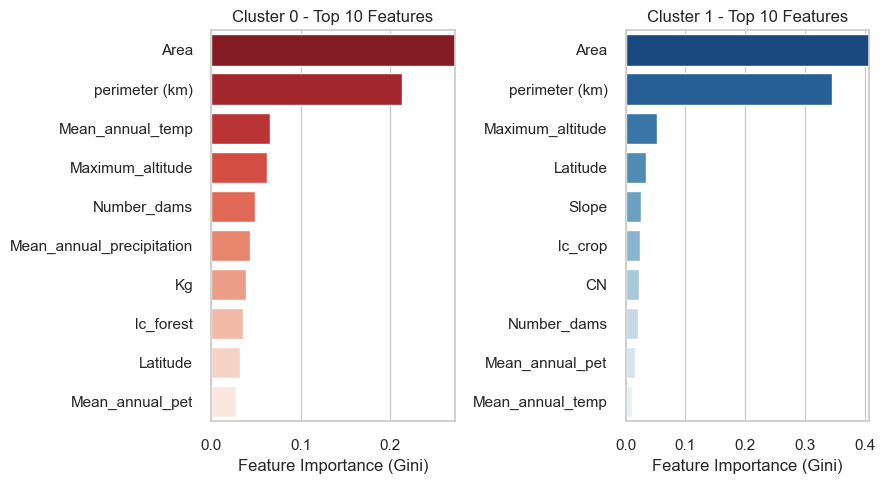

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load
import numpy as np

sns.set_theme(style="whitegrid")

feature_names = ['Area', 'Mean_altitude', 'Maximum_altitude', 'Minimum_altitude',
                 'Mean_annual_precipitation', 'Mean_annual_pet', 'Mean_annual_temp',
                 'lc_forest', 'lc_urban', 'lc_crop', 'lc_crop_irrig', 'lc_grass',
                 'lc_shrub', 'lc_sparse', 'lc_bare', 'Number_dams', 'Longitude', 'Latitude',
                 'CN', 'Slope', 'perimeter (km)', 'Kg']

plt.figure(figsize=(9, 5))
num_clusters = 2  # Set this to your actual number of clusters

for cluster in range(num_clusters):
    try:
        model = load(f'rf_cluster_{cluster}.joblib')
        
        # Get feature importances from Random Forest
        importance = model.feature_importances_
        
        # Sort features by importance
        sorted_idx = np.argsort(importance)[::-1]
        sorted_features = [feature_names[i] for i in sorted_idx]
        sorted_values = importance[sorted_idx]

        # Choose color palette
        if cluster == 0:
            palette = 'Reds_r'
        else:  # For cluster 1 (and beyond if needed)
            palette = 'Blues_r'

        # Create subplot
        plt.subplot(1, num_clusters, cluster+1)
        sns.barplot(x=sorted_values[:10], y=sorted_features[:10], palette=palette)
        plt.title(f'Cluster {cluster} - Top 10 Features')
        plt.xlabel('Feature Importance (Gini)')
        plt.ylabel('')
        plt.xlim(0, max(sorted_values[:10]))  # Fixed missing parenthesis here

    except FileNotFoundError:
        print(f"No model for Cluster {cluster}")
        continue

plt.tight_layout()
# plt.savefig('cluster_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

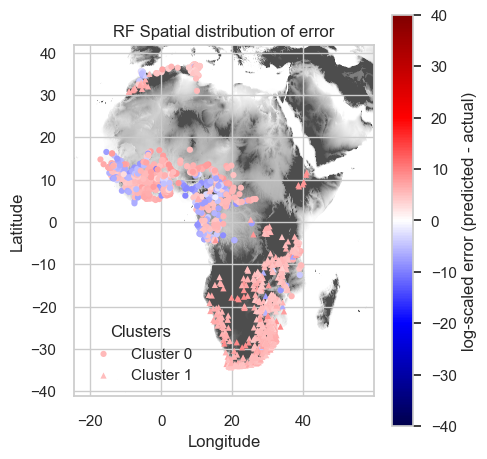

In [257]:
import pandas as pd
import xgboost as xgb
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib  # For loading models
import rasterio
from rasterio.plot import show
from matplotlib.colors import TwoSlopeNorm

# Set seaborn theme
sns.set_theme(style="whitegrid", font_scale=1)

# File paths
cluster_0_path = 'cluster_0.csv'
cluster_1_path = 'cluster_1.csv'
model_0_path = 'rf_cluster_0.joblib'  # XGBoost model for cluster 0
model_1_path = 'rf_cluster_1.joblib'  # XGBoost model for cluster 1
shapefile_path = 'maghreb.shp'
elevation_tif_path = 'elevation final.tif'

# Load the shapefile for the outline
gdf_outline = gpd.read_file(shapefile_path)

# Load the XGBoost models (assumed to be scikit-learn wrappers) using joblib
model_0 = joblib.load(model_0_path)
model_1 = joblib.load(model_1_path)

# Function to prepare data for prediction (excluding the target)
def prepare_data(df):
    features = df[[ 
        'Area','Mean_altitude','Maximum_altitude','Minimum_altitude',
        'Mean_annual_precipitation','Mean_annual_pet','Mean_annual_temp',
        'lc_forest','lc_urban','lc_crop','lc_crop_irrig','lc_grass',
        'lc_shrub','lc_sparse','lc_bare','Number_dams','Longitude','Latitude',
        'CN','Slope','perimeter (km)','Kg'
    ]]
    features = features.apply(pd.to_numeric, errors='coerce').dropna()
    return features

# Function to predict using the model (scikit-learn API)
def predict_with_xgb(model, features):
    features_array = np.array(features.values, dtype=np.float32)
    return model.predict(features_array)

# --- Process Cluster 0 ---
df_cluster_0 = pd.read_csv(cluster_0_path)
# Rename actual target column for clarity (if present)
if 'q99th' in df_cluster_0.columns:
    df_cluster_0.rename(columns={'q99th': 'q99th_actual'}, inplace=True)
features_0 = prepare_data(df_cluster_0)
predictions_0 = predict_with_xgb(model_0, features_0)
df_cluster_0['q99th_pred'] = predictions_0
# Compute the (signed) error: predicted minus actual
df_cluster_0['error'] = df_cluster_0['q99th_pred'] - df_cluster_0['q99th_actual']
# Apply the log-transformation (preserving the sign)
df_cluster_0['error_log'] = np.sign(df_cluster_0['error']) * np.log1p(np.abs(df_cluster_0['error']))

# --- Process Cluster 1 ---
df_cluster_1 = pd.read_csv(cluster_1_path)
if 'q99th' in df_cluster_1.columns:
    df_cluster_1.rename(columns={'q99th': 'q99th_actual'}, inplace=True)
features_1 = prepare_data(df_cluster_1)
predictions_1 = predict_with_xgb(model_1, features_1)
df_cluster_1['q99th_pred'] = predictions_1
df_cluster_1['error'] = df_cluster_1['q99th_pred'] - df_cluster_1['q99th_actual']
df_cluster_1['error_log'] = np.sign(df_cluster_1['error']) * np.log1p(np.abs(df_cluster_1['error']))

# Create GeoDataFrames using Longitude and Latitude
gdf_cluster_0 = gpd.GeoDataFrame(
    df_cluster_0,
    geometry=gpd.points_from_xy(df_cluster_0['Longitude'], df_cluster_0['Latitude']),
    crs="EPSG:4326"
)
gdf_cluster_1 = gpd.GeoDataFrame(
    df_cluster_1,
    geometry=gpd.points_from_xy(df_cluster_1['Longitude'], df_cluster_1['Latitude']),
    crs="EPSG:4326"
)

all_error_logs = np.concatenate([gdf_cluster_0['error_log'].values, gdf_cluster_1['error_log'].values])
#vmin = np.min(all_error_logs)
#vmax = np.max(all_error_logs)
vmin = -40
vmax = 40
# Center at 0
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Plotting using scatter for more control
fig, ax = plt.subplots(figsize=(5, 5))

# Plot the elevation raster as a backdrop

with rasterio.open(elevation_tif_path) as src:
    show(src, ax=ax, cmap='binary', alpha=0.7, vmin=0, vmax=1000)

# Plot the shapefile boundary
gdf_outline.boundary.plot(ax=ax, edgecolor='none', linewidth=1)

# Plot Cluster 0 and Cluster 1 points using the transformed error for coloring
sc0 = ax.scatter(
    gdf_cluster_0.geometry.x,
    gdf_cluster_0.geometry.y,
    c=gdf_cluster_0['error_log'],
    cmap='seismic',
    norm=norm,
    s=20,
    marker='o',
    edgecolor='none',
    label='Cluster 0'
)
sc1 = ax.scatter(
    gdf_cluster_1.geometry.x,
    gdf_cluster_1.geometry.y,
    c=gdf_cluster_1['error_log'],
    cmap='seismic',
    norm=norm,
    s=20,
    marker='^',
    edgecolor='none',
    label='Cluster 1'
)

# Add a colorbar to explain the error transformation
cbar = plt.colorbar(sc0, ax=ax)
cbar.set_label('log-scaled error (predicted - actual)')

ax.legend(title="Clusters", loc="lower left")
ax.set_title('RF Spatial distribution of error')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()


# SVM

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR  # Changed import
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical  # Added Categorical
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

# Updated parameter space for SVR
param_space = {
    'C': Real(1e-3, 500, prior='log-uniform'),              # Broader range for regularization
    'gamma': Real(1e-6, 10, prior='log-uniform'),           # More flexibility on the kernel coefficient
    'epsilon': Real(1e-4, 1.0, prior='log-uniform'),        # SVR epsilon-insensitive zone
    'kernel': Categorical(['rbf']),      # Trying additional kernels
    'degree': Integer(2, 5),                                # For polynomial kernel (if used)
    'shrinking': Categorical([True, False])                 # Optional: use shrinking heuristic or not
}

cluster_models = {}
results = {}

for cluster in range(K):
    print(f"\nTraining SVR model for Cluster {cluster+1}/{K}")
    
    train_mask = (train_clusters == cluster)
    test_mask = (test_clusters == cluster)
    
    X_train_cl = X_train[train_mask]
    y_train_cl = y_train[train_mask]
    X_test_cl = X_test[test_mask]
    y_test_cl = y_test[test_mask]
    
    if len(X_train_cl) == 0:
        print(f"Skipping cluster {cluster} - no training samples")
        continue
    
    svr = SVR()  # Changed model
    scoring = make_scorer(mean_squared_error, greater_is_better=False)
    
    opt = BayesSearchCV(
        svr,  # Changed estimator
        param_space,
        n_iter=50,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )
    
    opt.fit(X_train_cl, y_train_cl)
    
    cluster_models[cluster] = opt.best_estimator_
    
    if len(X_test_cl) > 0:
        y_pred = opt.best_estimator_.predict(X_test_cl)
        rmse = np.sqrt(mean_squared_error(y_test_cl, y_pred))
        results[cluster] = {
            'train_samples': len(X_train_cl),
            'test_samples': len(X_test_cl),
            'rmse': rmse,
            'best_params': opt.best_params_,
            'model': opt.best_estimator_
        }
        print(f"Cluster {cluster} RMSE: {rmse:.4f}")
    else:
        print(f"Cluster {cluster} has no test samples")

print("\nCluster Performance Summary:")
for cluster, res in results.items():
    print(f"Cluster {cluster}:")
    print(f"- Train samples: {res['train_samples']}")
    print(f"- Test samples: {res['test_samples']}")
    print(f"- Test RMSE: {res['rmse']:.4f}")
    print(f"- Best params: {res['best_params']}\n")


Training SVR model for Cluster 1/2
Cluster 0 RMSE: 395.0006

Training SVR model for Cluster 2/2
Cluster 1 RMSE: 1661.2348

Cluster Performance Summary:
Cluster 0:
- Train samples: 496
- Test samples: 223
- Test RMSE: 395.0006
- Best params: OrderedDict([('C', 499.99999999999994), ('degree', 2), ('epsilon', 1.0), ('gamma', 1e-06), ('kernel', 'rbf'), ('shrinking', False)])

Cluster 1:
- Train samples: 528
- Test samples: 216
- Test RMSE: 1661.2348
- Best params: OrderedDict([('C', 499.99999999999994), ('degree', 2), ('epsilon', 1.0), ('gamma', 1e-06), ('kernel', 'rbf'), ('shrinking', True)])



In [11]:
from joblib import dump

dump(scaler, 'cluster_scaler.joblib')       
dump(kmeans, 'cluster_kmeans.joblib')        

for cluster, model in cluster_models.items():
    dump(model, f'svm_cluster_{cluster}.joblib')

cluster_info = {
    'n_clusters': K,
    'train_distribution': np.bincount(train_clusters),
    'test_distribution': np.bincount(test_clusters)
}
dump(cluster_info, 'cluster_info.joblib')

['cluster_info.joblib']

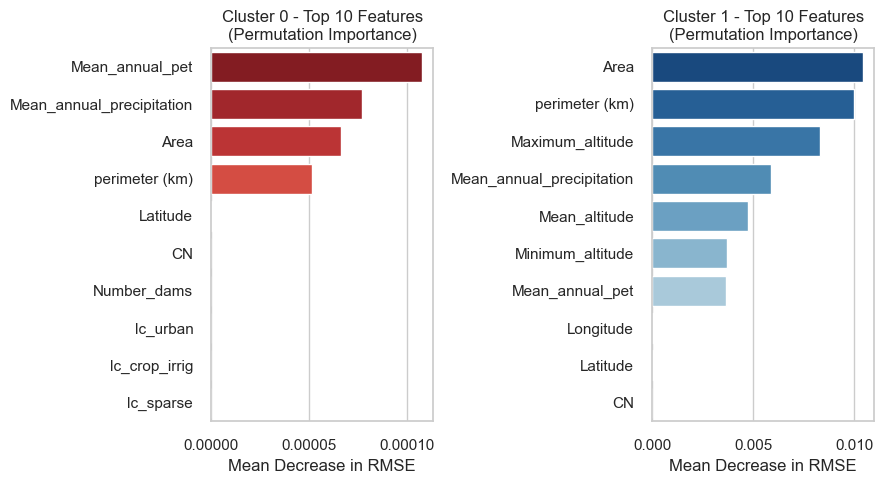

In [269]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# ... [keep all previous imports and data loading code] ...

feature_names = ['Area', 'Mean_altitude', 'Maximum_altitude', 'Minimum_altitude',
                 'Mean_annual_precipitation', 'Mean_annual_pet', 'Mean_annual_temp',
                 'lc_forest', 'lc_urban', 'lc_crop', 'lc_crop_irrig', 'lc_grass',
                 'lc_shrub', 'lc_sparse', 'lc_bare', 'Number_dams', 'Longitude', 'Latitude',
                 'CN', 'Slope', 'perimeter (km)', 'Kg']

plt.figure(figsize=(9, 5))
num_clusters = 2  # Set to your number of clusters

for cluster in range(num_clusters):
    try:
        model = load(f'svm_cluster_{cluster}.joblib')
        
        # Calculate permutation importance
        result = permutation_importance(
            model,
            X_test_cl,  # Use test data from the cluster
            y_test_cl,
            n_repeats=10,
            random_state=42,
            n_jobs=-1
        )
        
        # Sort features by importance
        sorted_idx = result.importances_mean.argsort()[::-1]
        sorted_features = [feature_names[i] for i in sorted_idx]
        sorted_values = result.importances_mean[sorted_idx]

        # Choose color palette
        palette = 'Blues_r' if cluster % 2 else 'Reds_r'

        # Create subplot
        plt.subplot(1, num_clusters, cluster+1)
        sns.barplot(x=sorted_values[:10], y=sorted_features[:10], palette=palette)
        plt.title(f'Cluster {cluster} - Top 10 Features\n(Permutation Importance)')
        plt.xlabel('Mean Decrease in RMSE')
        plt.ylabel('')
        
    except FileNotFoundError:
        print(f"No model for Cluster {cluster}")
        continue

plt.tight_layout()
plt.show()

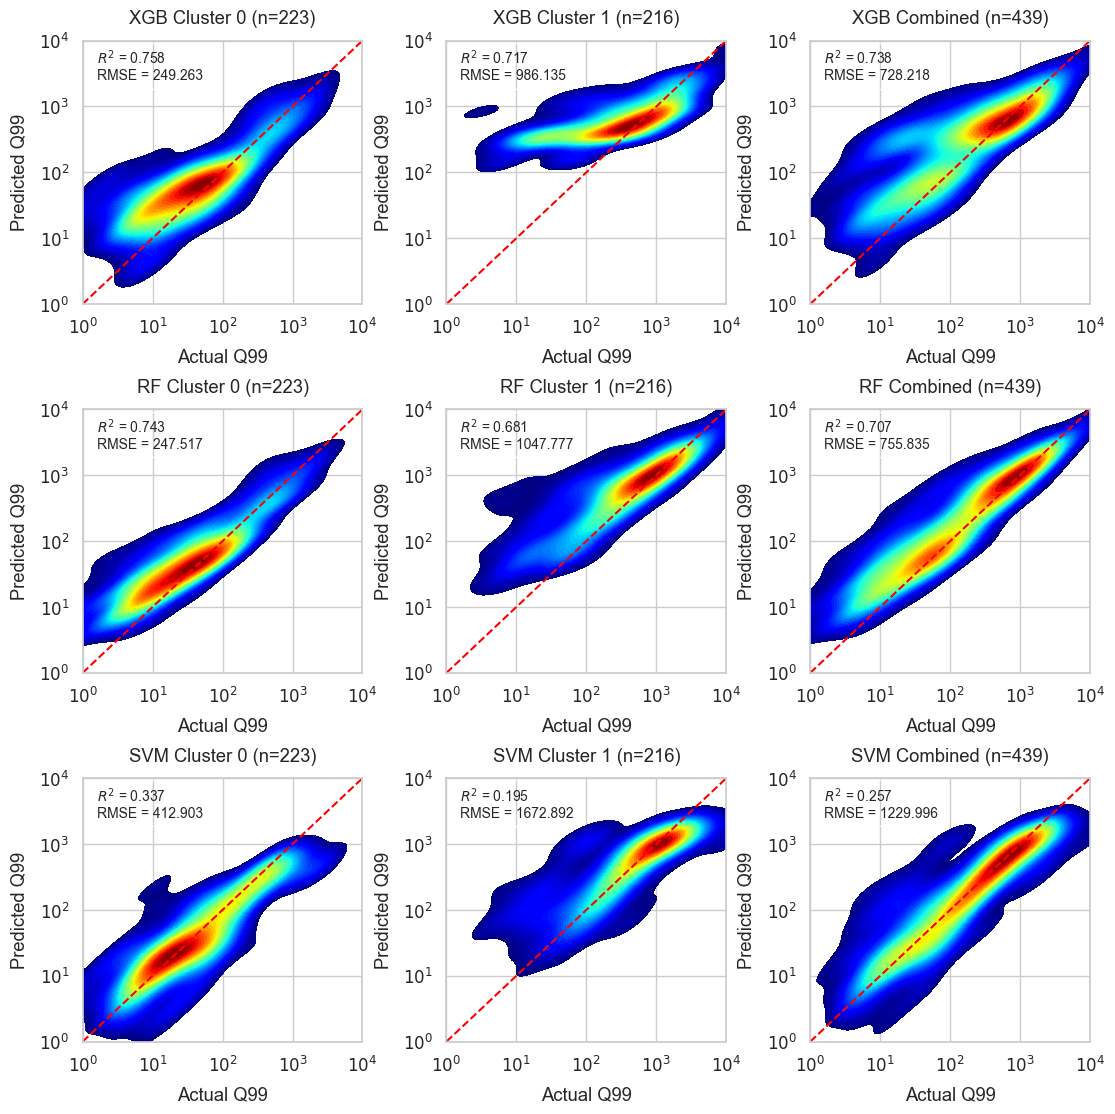

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.cm as cm
import joblib

sns.set_theme(style="whitegrid", font_scale=1.1)
#plt.rcParams['font.family'] = 'DejaVu Sans'  # Match font style

def clean_data(y_true, y_pred):
    # Implement your data cleaning logic here if needed
    mask = (y_true > 0) & (y_pred > 0)
    return y_true[mask], y_pred[mask]

def create_cluster_plot(y_true, y_pred, title, ax, x_min=1e0, x_max=1e4):
    """Create density plot for a single cluster"""
    y_true, y_pred = clean_data(y_true, y_pred)
    
    if len(y_true) == 0:
        ax.axis('off')
        return
    
    log_y_true = np.log10(y_true)
    log_y_pred = np.log10(y_pred)
    
    sns.kdeplot(
        x=log_y_true,
        y=log_y_pred,
        fill=True,
        cmap=cm.get_cmap('jet'),
        bw_adjust=0.8,
        thresh=0.1,
        levels=50,
        ax=ax
    )
    
    log_bins = np.linspace(np.log10(x_min), np.log10(x_max), 100)
    ax.plot(log_bins, log_bins, '--', color='red', linewidth=1.5, label='1:1 line')
    
    ax.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_xticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    ax.set_yticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_yticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    
    ax.set_xlim(np.log10(x_min), np.log10(x_max))
    ax.set_ylim(np.log10(x_min), np.log10(x_max))
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.text(0.05, 0.85, 
            f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}', 
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor='none', alpha=0.9))
    
    ax.set_title(title, pad=12)
    ax.set_xlabel('Actual Q99', labelpad=8)
    ax.set_ylabel('Predicted Q99', labelpad=8)

# Assuming you have X_test and y_test defined
models = ['XGB','RF', 'SVM']
K = 2  # Number of clusters for all models

fig = plt.figure(figsize=(13, 13))  # Adjusted for 3 rows
gs = fig.add_gridspec(len(models), K+1, wspace=0.3, hspace=0.4)

for row_idx, model_name in enumerate(models):
    # Load clustering artifacts
    scaler = joblib.load(f"{model_name}/cluster_scaler.joblib")
    kmeans = joblib.load(f"{model_name}/cluster_kmeans.joblib")
    
    # Load cluster models
    cluster_models = {}
    for cluster in range(K):
        cluster_models[cluster] = joblib.load(f"{model_name}/{model_name.lower()}_cluster_{cluster}.joblib")
    
    # Transform test data and predict clusters
    X_test_scaled = scaler.transform(X_test)
    test_clusters = kmeans.predict(X_test_scaled)
    
    all_y_test = []
    all_y_pred = []
    
    # Create cluster plots
    for cluster in range(K):
        ax = fig.add_subplot(gs[row_idx, cluster])
        test_mask = (test_clusters == cluster)
        y_test_cl = y_test[test_mask]
        
        if len(y_test_cl) == 0:
            ax.axis('off')
            continue
            
        y_pred_cl = cluster_models[cluster].predict(X_test[test_mask])
        
        all_y_test.append(y_test_cl)
        all_y_pred.append(y_pred_cl)
        
        create_cluster_plot(y_test_cl, y_pred_cl,
                           f'{model_name} Cluster {cluster} (n={len(y_test_cl)})',
                           ax)
    
    # Create combined plot for the row
    ax_combined = fig.add_subplot(gs[row_idx, K])
    if len(all_y_test) > 0:
        y_test_all = np.concatenate(all_y_test)
        y_pred_all = np.concatenate(all_y_pred)
        create_cluster_plot(y_test_all, y_pred_all,
                           f'{model_name} Combined (n={len(y_test_all)})',
                           ax_combined)
    else:
        ax_combined.axis('off')

plt.tight_layout()
plt.savefig('all_models_comparison.tif', dpi=300, bbox_inches='tight')
plt.show()

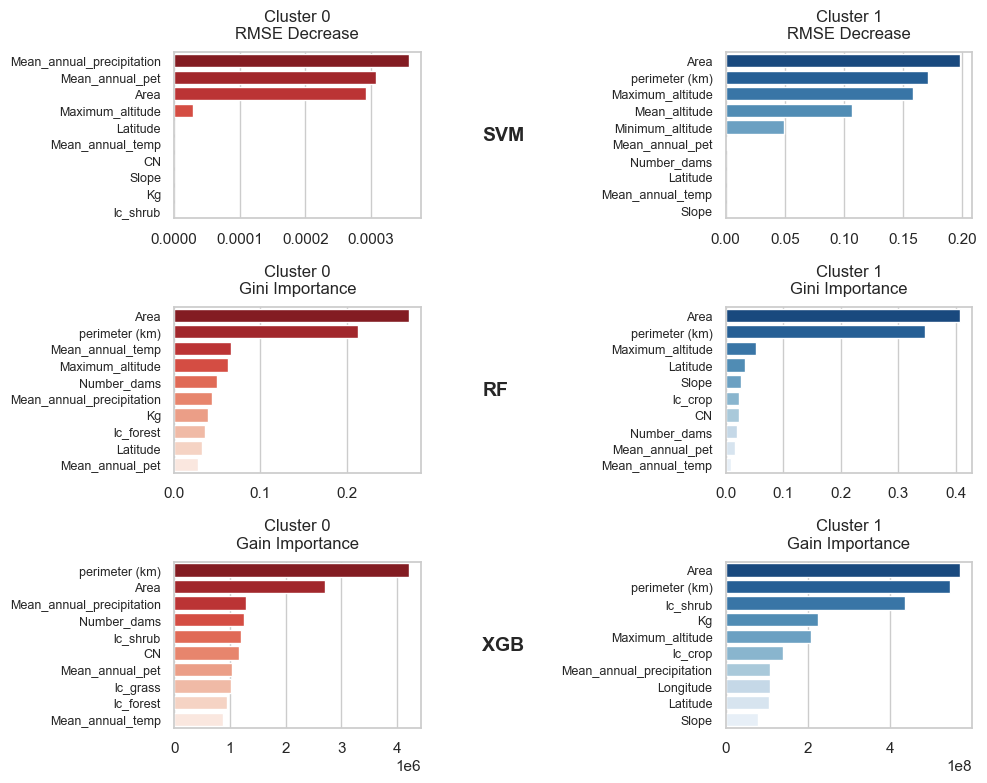

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

# Configure visual settings
sns.set_theme(style="whitegrid")
#plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 12

# Configuration
feature_names = [
    'Area', 'Mean_altitude', 'Maximum_altitude', 'Minimum_altitude',
    'Mean_annual_precipitation', 'Mean_annual_pet', 'Mean_annual_temp',
    'lc_forest', 'lc_urban', 'lc_crop', 'lc_crop_irrig', 'lc_grass',
    'lc_shrub', 'lc_sparse', 'lc_bare', 'Number_dams', 'Longitude', 'Latitude',
    'CN', 'Slope', 'perimeter (km)', 'Kg'
]

models = [
    ('SVM', 'permutation', 'RMSE Decrease'),
    ('RF', 'gini', 'Gini Importance'),
    ('XGB', 'gain', 'Gain Importance')
]

cluster_palettes = ['Reds_r', 'Blues_r']  # Consistent colors for clusters 0 and 1

# Create figure with 3 rows (models) × 2 columns (clusters)
fig, axs = plt.subplots(3, 2, figsize=(10, 8))
plt.subplots_adjust(hspace=0.5, wspace=0.4)

def prepare_data(df):
    """Prepare feature matrix from dataframe."""
    features = df[[ 
        'Area', 'Mean_altitude', 'Maximum_altitude', 'Minimum_altitude',
        'Mean_annual_precipitation', 'Mean_annual_pet', 'Mean_annual_temp',
        'lc_forest', 'lc_urban', 'lc_crop', 'lc_crop_irrig', 'lc_grass',
        'lc_shrub', 'lc_sparse', 'lc_bare', 'Number_dams', 'Longitude', 'Latitude',
        'CN', 'Slope', 'perimeter (km)', 'Kg'
    ]]
    return features.apply(pd.to_numeric, errors='coerce').dropna()

# Main processing loop
for row_idx, (model_name, imp_type, imp_label) in enumerate(models):
    # Add model type labels to leftmost column
    axs[row_idx, 0].annotate(
        model_name, xy=(1.25, 0.5), xycoords='axes fraction',
        fontsize=14, rotation=0, va='center', fontweight='bold'
    )
    
    for col_idx in range(2):  # Process both clusters
        ax = axs[row_idx, col_idx]
        cluster = col_idx
        palette = cluster_palettes[col_idx]

        try:
            # Load model and data
            model_path = f"{model_name}/{model_name.lower()}_cluster_{cluster}.joblib"
            model = load(model_path)
            cluster_df = pd.read_csv(f"{model_name}/cluster_{cluster}.csv")
            
            # Handle target column naming variations
            target_col = next((col for col in ['q99th_actual', 'q99th'] if col in cluster_df.columns), None)
            if not target_col:
                raise ValueError("Target column not found in CSV")
            
            # Prepare data
            X = prepare_data(cluster_df).values
            y = cluster_df[target_col].values

            # Calculate feature importance
            if imp_type == 'permutation':
                result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
                values = result.importances_mean
            elif imp_type == 'gini':
                values = model.feature_importances_
            elif imp_type == 'gain':
                booster = model.get_booster()
                importance = booster.get_score(importance_type='gain')
                values = np.array([importance.get(f'f{i}', 0) for i in range(len(feature_names))])

            # Sort features by importance
            sorted_idx = np.argsort(values)[::-1]
            sorted_features = [feature_names[i] for i in sorted_idx]
            sorted_values = values[sorted_idx]

            # Create bar plot
            sns.barplot(
                x=sorted_values[:10], 
                y=sorted_features[:10], 
                palette=palette,
                ax=ax
            )
            
            # Format subplot
            ax.set_title(f'Cluster {cluster}\n{imp_label}', pad=10)
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelsize=9)
            
            # Add cluster/model annotation
            ax.text(0.95, 0.92, 
                   f' ',
                   transform=ax.transAxes,
                   ha='right', va='bottom',
                   fontsize=10,
                   bbox=dict(facecolor='none', alpha=0))

        except Exception as e:
            ax.axis('off')
            print(f"Error in {model_name} Cluster {cluster}: {str(e)}")
            continue

# Final layout adjustments
plt.tight_layout()
plt.savefig('unified_feature_importance.tif', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
from joblib import load
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets, Dropdown, Output, VBox
import folium
from folium import Map, Marker
from IPython.display import display, clear_output

model1 = load('xgb_cluster_0.joblib')
model2 = load('xgb_cluster_1.joblib')

model_options = {
    "Lowland Accumulation-Flood Regime": model1,
    "Highland Flash-Flood Regime": model2
}


slider_specs = {
    'Area': (0.1, 5000.0, 0.1),
    'Mean_altitude': (0, 3000, 10),
    'Maximum_altitude': (0, 4000, 10),
    'Minimum_altitude': (0, 2000, 10),
    'Mean_annual_precipitation': (0, 2000, 10),
    'Mean_annual_pet': (0, 2000, 10),
    'Mean_annual_temp': (-10, 50, 0.5),
    'lc_forest': (0, 1, 0.01),
    'lc_urban': (0, 1, 0.01),
    'lc_crop': (0, 1, 0.01),
    'lc_crop_irrig': (0, 1, 0.01),
    'lc_grass': (0, 1, 0.01),
    'lc_shrub': (0, 1, 0.01),
    'lc_sparse': (0, 1, 0.01),
    'lc_bare': (0, 1, 0.01),
    'Number_dams': (0, 50, 1),
    'Longitude': (-180, 180, 0.01),
    'Latitude': (-90, 90, 0.01),
    'CN': (30, 100, 1),
    'Slope': (0, 100, 0.1),
    'perimeter (km)': (0, 300, 1),
    'Kg': (0, 200, 1)
}

input_widgets = {
    name: widgets.FloatSlider(
        value=(spec[0] + spec[1]) / 2,
        min=spec[0],
        max=spec[1],
        step=spec[2],
        description=name,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px')
    )
    for name, spec in slider_specs.items()
}

model_dropdown = Dropdown(
    options=list(model_options.keys()),
    description='Select Model:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

output_map = Output()
output_hydro = Output()

def generate_scs_hydrograph(Qp, tp=6, duration=24, dt=0.1):
    t = np.arange(0, duration, dt)
    q = np.zeros_like(t)

    for i, ti in enumerate(t):
        if ti < tp:
            q[i] = Qp * (ti / tp) ** 2.4  # rising limb
        else:
            decay = np.exp(-0.5 * (ti - tp))
            q[i] = Qp * decay
    return t, q

def predict_and_plot(selected_model, **kwargs):
    model = model_options[selected_model]
    X_input = np.array([list(kwargs.values())]).reshape(1, -1)
    prediction = model.predict(X_input)[0]

    print(f"\n🌊 Predicted 100-years Peak Discharge: {prediction:.2f} m³/s")

    lat, lon = kwargs['Latitude'], kwargs['Longitude']
    with output_map:
        clear_output(wait=True)
        m = Map(location=[lat, lon], zoom_start=6)
        Marker([lat, lon], popup="📍 Selected Location").add_to(m)
        display(m)

    with output_hydro:
        clear_output(wait=True)
        t, q = generate_scs_hydrograph(prediction)
        plt.figure(figsize=(8, 4))
        plt.plot(t, q, color='dodgerblue', lw=2)
        plt.title("SCS Synthetic Hydrograph")
        plt.xlabel("Time (hours)")
        plt.ylabel("Discharge (m³/s)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

interact(
    predict_and_plot,
    selected_model=model_dropdown,
    **input_widgets
)

display(VBox([output_map, output_hydro]))


interactive(children=(Dropdown(description='Select Model:', layout=Layout(width='300px'), options=('Lowland Ac…